# EE4216 Image Processing and Computer Vision

## Assignment 03

### Development of a Handwritten Digit Recognition System using Convolutional Neural Networks

Name: CHANDRAMOHAN NIMALRAJ

Registration Number: 20010216006

Step 1.1 – Import Required Libraries

In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


Step 1.2 – Load the MNIST Dataset

In [25]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Dataset loaded successfully!")

Dataset loaded successfully!


Step 1.3 – Check the Dataset

In [26]:
print("Training Images :", x_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images  :", x_test.shape)
print("Testing Labels  :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)


## Step 1.4 – Display Sample Images

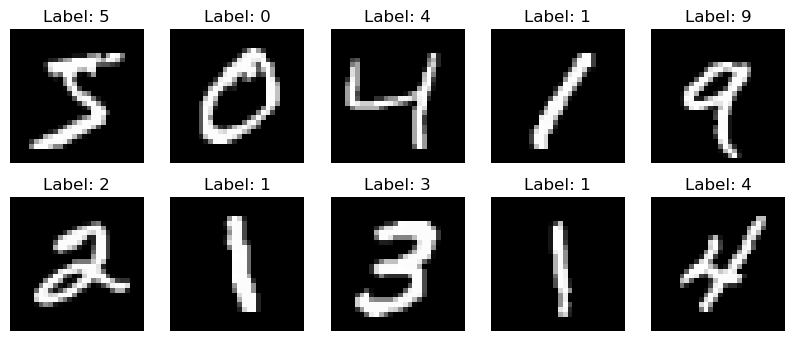

In [27]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Label: " + str(y_train[i]))
    plt.axis('off')

plt.show()

## Step 1.5 – Normalize the Images

In [28]:
# Normalize pixel values

x_train = x_train / 255.0
x_test = x_test / 255.0

print("Normalization completed!")

Normalization completed!


Verify the Normalization

In [29]:
print("Minimum Pixel Value :", x_train.min())
print("Maximum Pixel Value :", x_train.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


## Step 1.6 – Reshape the Images

In [30]:
# Reshape images for CNN input

x_train = x_train.reshape(60000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

print("Reshaping completed!")

Reshaping completed!


Verify the Shape

In [31]:
print("Training Images Shape :", x_train.shape)
print("Testing Images Shape  :", x_test.shape)

Training Images Shape : (60000, 28, 28, 1)
Testing Images Shape  : (10000, 28, 28, 1)


## Step 2.1 – Import CNN Layers

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

## Step 2.2 – Build the Convolutional Neural Network (CNN)

In this step, a Convolutional Neural Network (CNN) model is created using TensorFlow Keras. The architecture consists of two convolutional layers, two max pooling layers, a flatten layer, one fully connected (dense) hidden layer, and an output layer with 10 neurons for classifying handwritten digits (0–9).

In [42]:
model = Sequential()

# First Convolution + Pooling Layer
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second Convolution + Pooling Layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

# Display Model Summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Step 2.3 – Compile the CNN Model

In this step, the CNN model is compiled by specifying the optimizer, loss function, and evaluation metric. The Adam optimizer is used for efficient learning, Sparse Categorical Crossentropy is used as the loss function for multi-class classification, and Accuracy is used to evaluate the model performance.

In [43]:
# Compile the CNN model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


## Step 3.1 – Train the CNN Model

The CNN model is trained using the MNIST training dataset. Validation data is used to monitor the model performance during training. The model is trained for 10 epochs.

In [44]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9464 - loss: 0.1788 - val_accuracy: 0.9819 - val_loss: 0.0632
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9836 - loss: 0.0528 - val_accuracy: 0.9862 - val_loss: 0.0478
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9889 - loss: 0.0364 - val_accuracy: 0.9893 - val_loss: 0.0374
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9918 - loss: 0.0261 - val_accuracy: 0.9865 - val_loss: 0.0432
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9936 - loss: 0.0204 - val_accuracy: 0.9884 - val_loss: 0.0416
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9948 - loss: 0.0161 - val_accuracy: 0.9854 - val_loss: 0.0484
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9961 - loss: 0.0123 - val_accuracy: 0.9903 - val_loss: 0.0372
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9959 - loss: 0.0112 - val_accuracy:

## Step 3.2 – Training and Validation Accuracy

The graph below shows the training and validation accuracy of the CNN model over 10 epochs. It illustrates how the model performance improves during training.

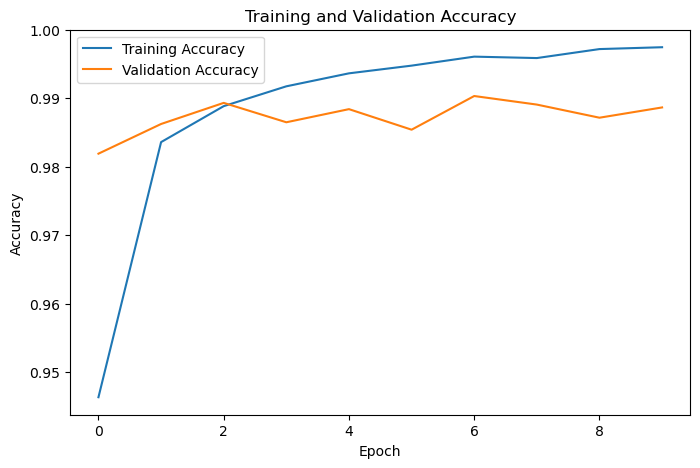

In [45]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## Step 3.3 – Training and Validation Loss

The graph below shows the training and validation loss during the training process. A decreasing loss indicates that the model is learning effectively.

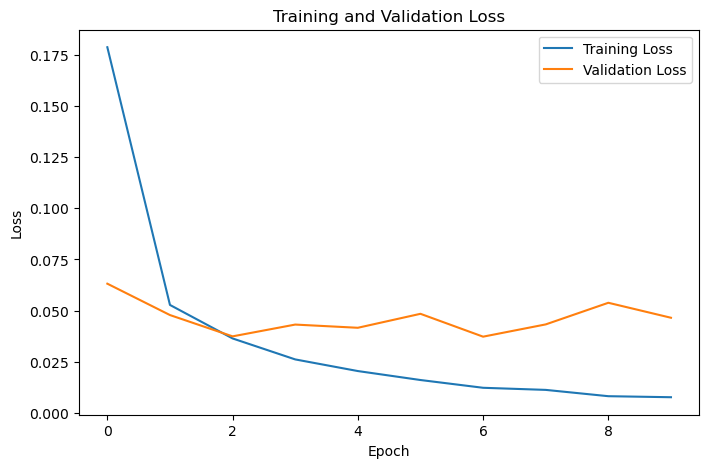

In [46]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Step 4.1 – Evaluate the CNN Model

The trained CNN model is evaluated using the MNIST test dataset. The evaluation provides the overall test loss and test accuracy, which indicate how well the model performs on unseen data.

In [47]:
# Evaluate the model using the test dataset

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9910 - loss: 0.0396
Test Loss : 0.03964528068900108
Test Accuracy : 0.9909999966621399


## Step 4.2 – Generate Predictions

The trained CNN model is used to predict the handwritten digit labels for the MNIST test dataset. The predicted probabilities are converted into digit labels using the maximum probability.

In [48]:
# Predict the test dataset

predictions = model.predict(x_test)

# Convert probabilities into digit labels

predicted_labels = predictions.argmax(axis=1)

print("Predictions generated successfully!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predictions generated successfully!


## Step 4.3 – Display Sample Predictions

The following images show sample handwritten digits together with their actual labels and the labels predicted by the CNN model.

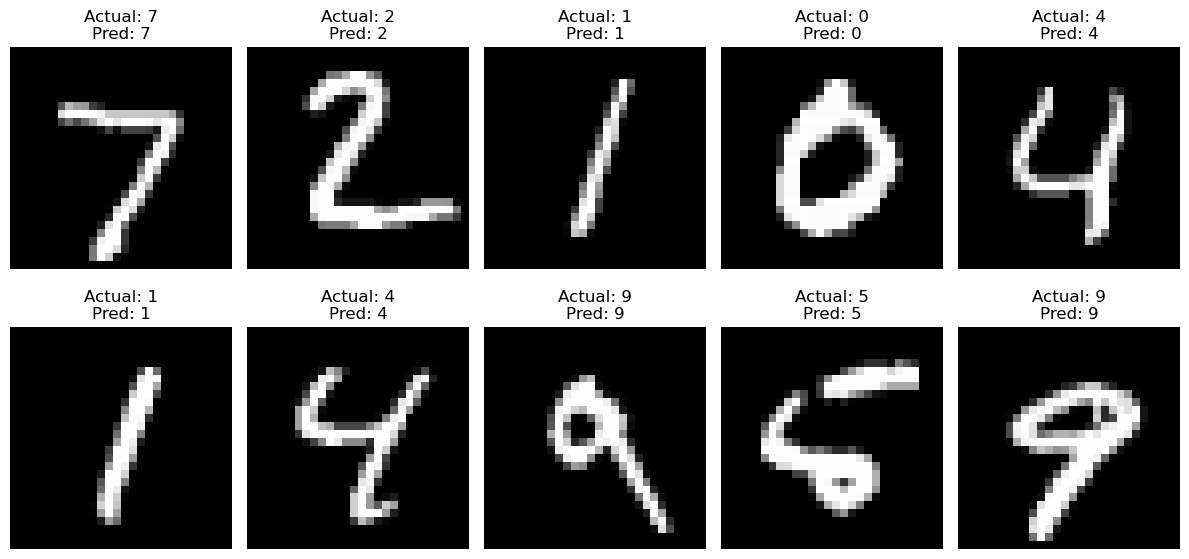

In [49]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)

    plt.imshow(x_test[i].reshape(28,28), cmap='gray')

    plt.title(f"Actual: {y_test[i]}\nPred: {predicted_labels[i]}")

    plt.axis('off')

plt.tight_layout()
plt.show()

## Step 4.4 – Generate the Confusion Matrix

A confusion matrix is generated to evaluate the classification performance of the CNN model by comparing the actual digit labels with the predicted labels.

In [50]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

<Figure size 800x800 with 0 Axes>

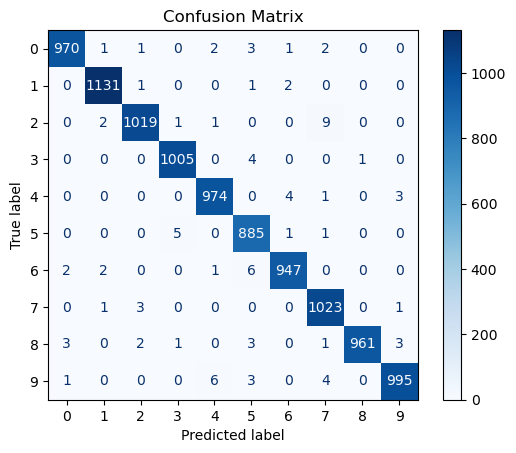

In [51]:
cm = confusion_matrix(y_test, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(8,8))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## Step 4.5 – Display Misclassified Images

The following images were incorrectly classified by the CNN model. Displaying these images helps to identify the types of handwritten digits that are difficult for the model to recognize.

In [52]:
# Find misclassified images

misclassified = np.where(predicted_labels != y_test)[0]

print("Total Misclassified Images:", len(misclassified))

Total Misclassified Images: 90


Display the first 10 misclassified images

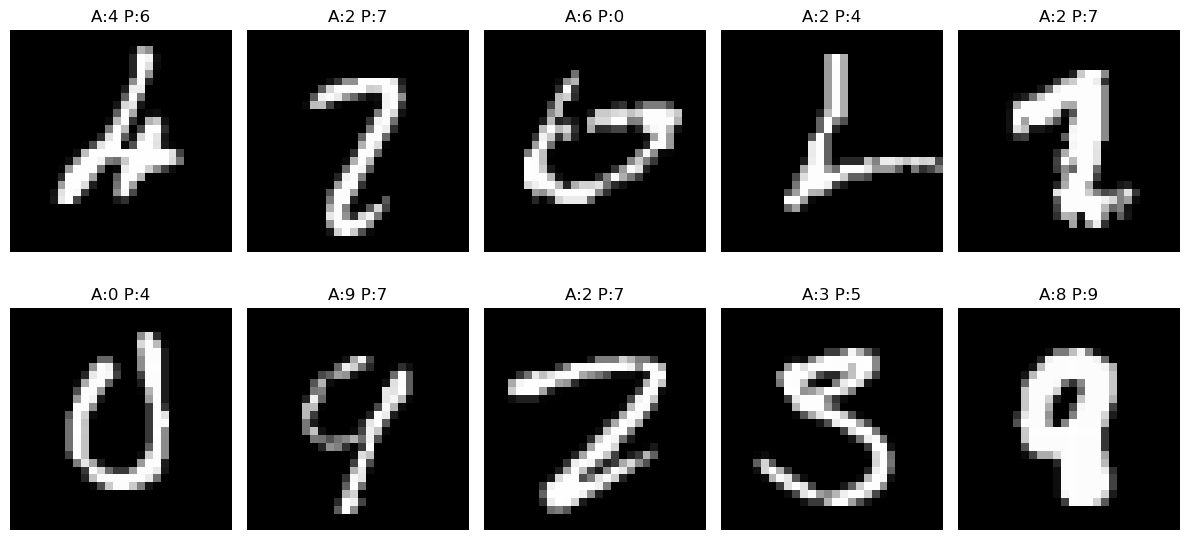

In [53]:
plt.figure(figsize=(12, 6))

for i in range(10):

    index = misclassified[i]

    plt.subplot(2, 5, i + 1)

    plt.imshow(x_test[index].reshape(28, 28), cmap='gray')

    plt.title(f"A:{y_test[index]} P:{predicted_labels[index]}")

    plt.axis('off')

plt.tight_layout()

plt.show()

## Step 5.1 – Import OpenCV

OpenCV is used to read, preprocess, and resize the custom handwritten digit images before they are given to the trained CNN model.

In [54]:
import cv2
import os

## Step 5.2 – Load Custom Handwritten Images

The handwritten digit images are loaded from the local folder for preprocessing and prediction.

In [55]:
image_folder = "handwritten"

image_files = sorted(os.listdir(image_folder))

print(image_files)

['0.png', '2.png', '4.png', '6.png', '8.png']


Step 5.3 – Preprocess and Predict Custom Handwritten Digits

In [64]:
custom_images = []
custom_labels = []

for file_name in image_files:
    image_path = os.path.join(image_folder, file_name)

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Invert: black digit on white background -> white digit on black background
    img = 255 - img

    # Threshold to make digit clear
    _, img = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY)

    # Find digit boundary
    coords = cv2.findNonZero(img)
    x, y, w, h = cv2.boundingRect(coords)

    # Crop digit
    img = img[y:y+h, x:x+w]

    # Resize digit to 20x20
    img = cv2.resize(img, (20, 20))

    # Add padding to make 28x28
    img = np.pad(img, ((4, 4), (4, 4)), mode='constant', constant_values=0)

    # Normalize
    img = img / 255.0

    img_input = img.reshape(1, 28, 28, 1)

    prediction = model.predict(img_input)
    predicted_digit = np.argmax(prediction)

    custom_images.append(img)
    custom_labels.append(predicted_digit)

    print(file_name, "→ Predicted Digit:", predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
0.png → Predicted Digit: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2.png → Predicted Digit: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4.png → Predicted Digit: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
6.png → Predicted Digit: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
8.png → Predicted Digit: 8


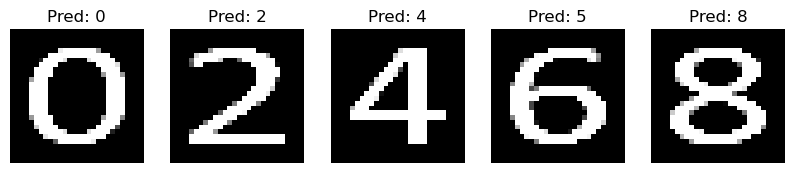

In [65]:
plt.figure(figsize=(10, 4))

for i in range(len(custom_images)):
    plt.subplot(1, len(custom_images), i + 1)
    plt.imshow(custom_images[i], cmap='gray')
    plt.title(f"Pred: {custom_labels[i]}")
    plt.axis('off')

plt.show()

# Conclusion

A Convolutional Neural Network (CNN) was successfully developed for handwritten digit recognition using the MNIST dataset. The model achieved a training accuracy of approximately 99.75% and a test accuracy of 99.10%. It demonstrated excellent performance on the standard MNIST dataset and correctly classified most custom handwritten digit images. The experimental results confirm that CNNs are highly effective for handwritten digit recognition, although slight variations in custom handwriting styles may lead to occasional misclassification.